# Step 3: Comprehensive Exploratory Data Analysis (EDA)
In this notebook, we perform a deep dive into our Target Variable using state-of-the-art profiling libraries: `ydata-profiling`, `Sweetviz`, and `D-Tale`.

**Important Memory Strategy:** 
Since the raw ER datasets contain over a hundred million records (which would crash these libraries in RAM), we first use DuckDB to aggregate the data at the daily level per hospital. This brings the dataset to a highly informative and memory-safe size for profiling.

In [1]:
import duckdb
import pandas as pd
import sweetviz as sv
from ydata_profiling import ProfileReport
import dtale
import warnings
warnings.filterwarnings('ignore')

print("=== EXTRACTING AGGREGATED TARGET VARIABLE VIA DUCKDB ===")

# Aggregate to Daily Respiratory Urgencies per Hospital
query_eda = """
SELECT 
    fecha,
    IdEstablecimiento,
    NEstablecimiento,
    SUM(Total) as Total_Respiratorias,
    SUM(Menores_1) as Menores_1,
    SUM(De_1_a_4) as De_1_a_4,
    SUM(De_5_a_14) as De_5_a_14,
    SUM(De_15_a_64) as De_15_a_64,
    SUM(De_65_y_mas) as Mayores_65
FROM read_parquet('../data/processed/urgencias_parquet/*.parquet')
WHERE GlosaCausa LIKE '%RESPIRATORIO%'
GROUP BY fecha, IdEstablecimiento, NEstablecimiento
"""

df_eda = duckdb.query(query_eda).df()

# Format Date
df_eda['fecha'] = pd.to_datetime(df_eda['fecha'], format='%d/%m/%Y', errors='coerce')
df_eda = df_eda.dropna(subset=['fecha']).sort_values('fecha')

print(f"Extracted {len(df_eda)} daily aggregated records for profiling.")
display(df_eda.head())

C:\Users\Usuario\AppData\Local\Temp\ipykernel_28368\531674180.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


=== EXTRACTING AGGREGATED TARGET VARIABLE VIA DUCKDB ===


Extracted 1485513 daily aggregated records for profiling.


,fecha,IdEstablecimiento,NEstablecimiento,Total_Respiratorias,Menores_1,De_1_a_4,De_5_a_14,De_15_a_64,Mayores_65
186315,2017-01-01,07-108,Hospital Adriana Cousiño (Quintero),17.0,1.0,4.0,1.0,10.0,1.0
293600,2017-01-01,07-327,Centro de Salud Familiar Las Torres,28.0,4.0,3.0,3.0,16.0,2.0
971758,2017-01-01,05-300,Centro de Salud Familiar Cardenal Caro,14.0,1.0,0.0,1.0,10.0,2.0
1313789,2017-01-01,13-815,SAPU-Confraternidad,21.0,0.0,8.0,2.0,10.0,1.0
787482,2017-01-01,16-829,SAR Dr. Juan Saavedra Macaya,10.0,0.0,3.0,2.0,4.0,1.0


### 1. Sweetviz Profiling
Sweetviz creates highly visual and comparative HTML reports.

In [2]:
print("\n=== GENERATING SWEETVIZ REPORT ===")
sv_report = sv.analyze(df_eda)
sv_report.show_html('Sweetviz_EDA_Report.html', open_browser=False)
print("Sweetviz report successfully saved to 'Sweetviz_EDA_Report.html'")


=== GENERATING SWEETVIZ REPORT ===


                                             |          | [  0%]   00:00 -> (? left)

Report Sweetviz_EDA_Report.html was generated.
Sweetviz report successfully saved to 'Sweetviz_EDA_Report.html'


### 2. YData Profiling
Generates a comprehensive standardized statistical report.

In [3]:
print("\n=== GENERATING YDATA-PROFILING REPORT ===")
profile = ProfileReport(df_eda, title="Respiratory Urgencies Profiling Report", explorative=True, minimal=True)
profile.to_file("YData_EDA_Report.html")
print("YData Profiling report successfully saved to 'YData_EDA_Report.html'")


=== GENERATING YDATA-PROFILING REPORT ===


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

 11%|█         | 1/9 [00:01<00:11,  1.41s/it]

100%|██████████| 9/9 [00:01<00:00,  6.17it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

YData Profiling report successfully saved to 'YData_EDA_Report.html'


### 3. D-Tale Interactive Exploration
Uncomment and run the cell below in your local Jupyter environment to launch the D-Tale GUI.

In [4]:
d = dtale.show(df_eda)
d.open_browser()

### 4. Skewness Correction (Log1p Transformation)
As observed in the EDA reports, the distribution of Emergency Room visits is highly right-skewed (asymmetrical to the left), meaning most days have lower counts, but there are massive outliers/spikes during winter or outbreaks.

Highly skewed variables degrade machine learning performance (especially in Neural Networks like TFT). The logical solution is to apply a logarithmic transformation (`log1p`) to normalize the distributions.

=== SKEWNESS METRICS ===
Original Skewness:
 Total_Respiratorias      6.195845
Menores_1               37.372987
De_1_a_4               168.762464
De_5_a_14                2.906282
De_15_a_64               2.162486
Mayores_65               3.017195
dtype: float64



Transformed Skewness (Log1p):
 Total_Respiratorias   -0.533257
Menores_1              1.255614
De_1_a_4               0.350973
De_5_a_14              0.267758
De_15_a_64            -0.226381
Mayores_65             0.425222
dtype: float64

=== VISUAL COMPARISON (BEFORE VS AFTER) ===


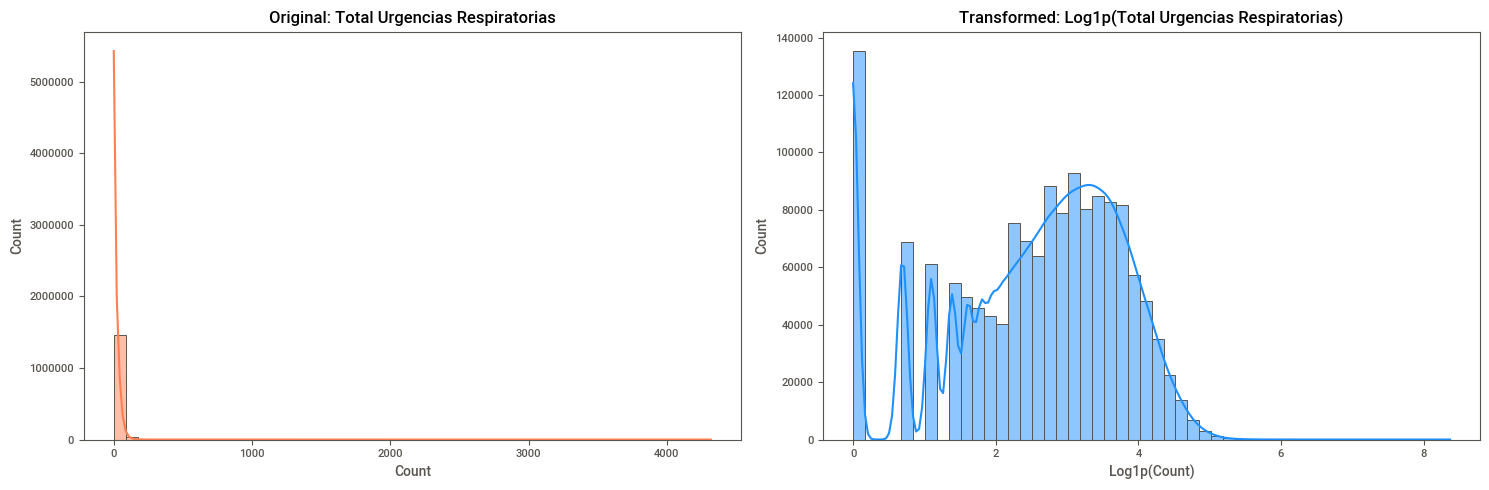


--- Textual Data Output for the Plot ---
Data: Skewness reduction metrics
Original Skew (Total_Respiratorias): 6.1958
Transformed Skew (Total_Respiratorias): -0.5333
------------------------------------------


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=== SKEWNESS METRICS ===")
cols_to_check = ['Total_Respiratorias', 'Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'Mayores_65']
print("Original Skewness:\n", df_eda[cols_to_check].skew())

# Apply Log1p Transformation
df_log = df_eda[cols_to_check].apply(np.log1p)
print("\nTransformed Skewness (Log1p):\n", df_log.skew())

print("\n=== VISUAL COMPARISON (BEFORE VS AFTER) ===")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_eda['Total_Respiratorias'], bins=50, ax=axes[0], color='coral', kde=True)
axes[0].set_title('Original: Total Urgencias Respiratorias')
axes[0].set_xlabel('Count')

sns.histplot(df_log['Total_Respiratorias'], bins=50, ax=axes[1], color='dodgerblue', kde=True)
axes[1].set_title('Transformed: Log1p(Total Urgencias Respiratorias)')
axes[1].set_xlabel('Log1p(Count)')

plt.tight_layout()
plt.show()

# REQUIRED TEXT OUTPUT
print("\n--- Textual Data Output for the Plot ---")
print("Data: Skewness reduction metrics")
print(f"Original Skew (Total_Respiratorias): {df_eda['Total_Respiratorias'].skew():.4f}")
print(f"Transformed Skew (Total_Respiratorias): {df_log['Total_Respiratorias'].skew():.4f}")
print("------------------------------------------")